In [1]:
import os, random, pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

DATA_CSV = "lstm_data.csv"
FEATURE_COLS = ["temperature", "pressure", "humidity", "gas_resistance"]
SEQ_LEN = 10
N_FEATURES = len(FEATURE_COLS)  

TRAIN_NOISE_STDS = [0.1, 0.2, 0.3, 0.4, 0.5]
TEST_NOISE_STDS  = [0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]

EPOCHS_CLF     = 100
EPOCHS_DENOISE = 150
BATCH_SIZE     = 64
LR             = 1e-3
SEED           = 42

np.random.seed(SEED) 
tf.random.set_seed(SEED)
random.seed(SEED)

print("CONFIG OK")

CONFIG OK


In [2]:
df = pd.read_csv(DATA_CSV)
df["gas_resistance"] = np.log1p(df["gas_resistance"])
df = df.sort_values(["id", "position"])

complete_ids = [gid for gid, grp in df.groupby("id") if len(grp) == SEQ_LEN]
df = df[df["id"].isin(complete_ids)]

print(f"Total fingerprints: {len(complete_ids)}")
for cls, n in df.drop_duplicates("id")["label"].value_counts().sort_index().items():
    print(f"  {cls}: {n}")

Total fingerprints: 7102
  air: 1437
  basil: 1407
  cinnamon: 1401
  oregano: 1420
  rosemary: 1437


In [3]:
all_ids   = np.array(complete_ids)
label_map = df.drop_duplicates("id").set_index("id")["label"].to_dict()
y_ids     = np.array([label_map[i] for i in all_ids])

train_ids, test_ids = train_test_split(
    all_ids, test_size=0.3, stratify=y_ids, random_state=SEED
)

train_df = df[df["id"].isin(train_ids)].copy()
test_df  = df[df["id"].isin(test_ids)].copy()

scaling_stats = {}
train_sc, test_sc = train_df.copy(), test_df.copy()

for feat in FEATURE_COLS:
    means = train_df.groupby("plate_temperature")[feat].mean()
    stds  = train_df.groupby("plate_temperature")[feat].std().replace(0, 1.0)
    gm, gs = train_df[feat].mean(), train_df[feat].std() or 1.0
    scaling_stats[feat] = {"mean": means, "std": stds}

    train_sc[feat] = (train_df[feat] - train_df["plate_temperature"].map(means)) / \
                      train_df["plate_temperature"].map(stds)
    m = test_df["plate_temperature"].map(means).fillna(gm)
    s = test_df["plate_temperature"].map(stds).fillna(gs).replace(0, 1.0)
    test_sc[feat] = (test_df[feat] - m) / s

print(f"Train: {len(train_ids)}  Test: {len(test_ids)}")

Train: 4971  Test: 2131


In [4]:
le = LabelEncoder()
train_sc["label_enc"] = le.fit_transform(train_sc["label"])
test_sc["label_enc"]  = le.transform(test_sc["label"])
NUM_CLASSES = len(le.classes_)
print(f"Classes ({NUM_CLASSES}): {le.classes_}")

def make_sequences(df, feature_cols, seq_len):
    X, y = [], []
    for _, grp in df.groupby("id"):
        grp = grp.sort_values("position")
        if len(grp) == seq_len:
            X.append(grp[feature_cols].values.astype(np.float32))
            y.append(int(grp["label_enc"].iloc[0]))
    return np.array(X), np.array(y)

X_tr, y_tr = make_sequences(train_sc, FEATURE_COLS, SEQ_LEN)
X_te, y_te = make_sequences(test_sc,  FEATURE_COLS, SEQ_LEN)
print(f"X_tr: {X_tr.shape}  X_te: {X_te.shape}")

Classes (5): ['air' 'basil' 'cinnamon' 'oregano' 'rosemary']
X_tr: (4971, 10, 4)  X_te: (2131, 10, 4)


In [5]:
rng = np.random.default_rng(SEED)

X_noisy_all, X_clean_all = [], []
for std in TRAIN_NOISE_STDS:
    noise = rng.standard_normal(X_tr.shape).astype(np.float32) * std
    X_noisy_all.append(X_tr + noise)
    X_clean_all.append(X_tr)

X_noisy_all = np.concatenate(X_noisy_all)
X_clean_all = np.concatenate(X_clean_all)

idx = rng.permutation(len(X_noisy_all))
X_noisy_all, X_clean_all = X_noisy_all[idx], X_clean_all[idx]

split = int(0.9 * len(X_noisy_all))
Xn_tr, Xn_val = X_noisy_all[:split], X_noisy_all[split:]
Xc_tr, Xc_val = X_clean_all[:split], X_clean_all[split:]

print(f"Denoiser train pairs: {len(Xn_tr)}  val: {len(Xn_val)}")
print(f"Noise levels: {TRAIN_NOISE_STDS}")

Denoiser train pairs: 22369  val: 2486
Noise levels: [0.1, 0.2, 0.3, 0.4, 0.5]


In [6]:
def build_denoiser(seq_len, n_features):
    inp = keras.Input(shape=(seq_len, n_features))

    e1 = layers.Conv1D(64,  3, padding="same", activation="relu")(inp)
    e1 = layers.BatchNormalization()(e1)
    e2 = layers.Conv1D(128, 3, padding="same", activation="relu")(e1)
    e2 = layers.BatchNormalization()(e2)

    b  = layers.Conv1D(128, 3, padding="same", activation="relu")(e2)
    b  = layers.BatchNormalization()(b)

    d1 = layers.Conv1D(128, 3, padding="same", activation="relu")(
             layers.Concatenate()([b, e2]))
    d1 = layers.BatchNormalization()(d1)
    d2 = layers.Conv1D(64,  3, padding="same", activation="relu")(
             layers.Concatenate()([d1, e1]))
    d2 = layers.BatchNormalization()(d2)

    correction = layers.Conv1D(n_features, 1, padding="same",
                               kernel_initializer="zeros")(d2)
    out = layers.Add()([inp, correction])  # residual

    model = keras.Model(inputs=inp, outputs=out, name="CNN_Denoiser")
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
    return model

denoiser = build_denoiser(SEQ_LEN, N_FEATURES)
denoiser.summary()

Model: "CNN_Denoiser"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 128)   │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 256)   │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 128)   │     98,432 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 10, 192)   │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 64)    │     36,928 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 10, 4)     │        260 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 4)     │          0 │ input_layer[0][0… │
│                     │                   │            │ conv1d_5[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 212,484 (830.02 KB)

 Trainable params: 211,460 (826.02 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0236 - mae: 0.1107 - val_loss: 0.0274 - val_mae: 0.1227 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0160 - mae: 0.0924 - val_loss: 0.0152 - val_mae: 0.0899 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.0148 - mae: 0.0886 - val_loss: 0.0148 - val_mae: 0.0887 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 0.0141 - mae: 0.0865 - val_loss: 0.0142 - val_mae: 0.0866 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - loss: 0.0136 - mae: 0.0849 - val_loss: 0.0139 - val_mae: 0.0851 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - loss: 0.0133 - mae: 0.0837 - val_loss: 0.0137 - val_mae: 0.0845 - learning_rate: 0.0010
Epoch 7/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - loss: 0.0130 - mae: 0.0828 - val_loss: 0.0136 - val_mae: 0.0839 - learning

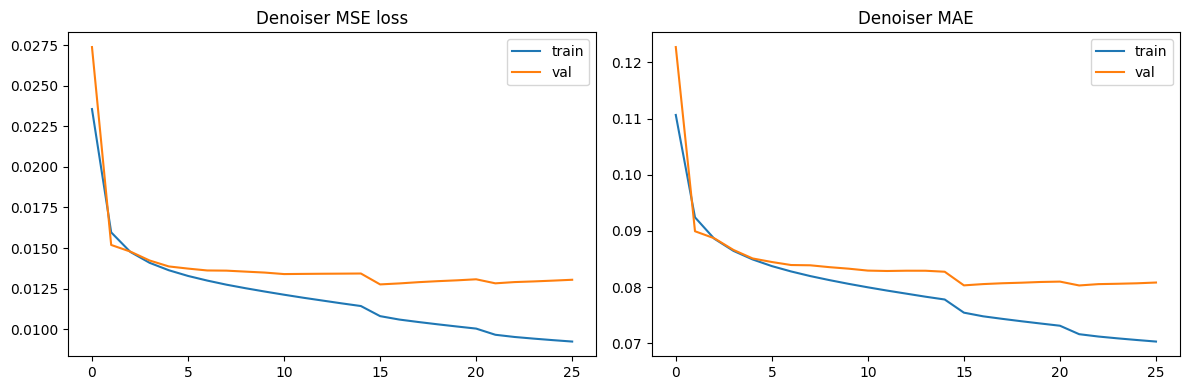

In [7]:
hist_d = denoiser.fit(
    Xn_tr, Xc_tr,
    validation_data=(Xn_val, Xc_val),
    epochs=EPOCHS_DENOISE,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_d.history["loss"], label="train")
ax1.plot(hist_d.history["val_loss"], label="val")
ax1.set_title("Denoiser MSE loss"); ax1.legend()
ax2.plot(hist_d.history["mae"], label="train")
ax2.plot(hist_d.history["val_mae"], label="val")
ax2.set_title("Denoiser MAE"); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
print(f"{'Noise std':<12} {'MSE noisy':>12} {'MSE denoised':>14} {'Reduction':>11}")

rng_check = np.random.default_rng(99)
for std in TEST_NOISE_STDS:
    noise     = rng_check.standard_normal(X_te.shape).astype(np.float32) * std
    X_corrupt = X_te + noise
    X_fixed   = denoiser.predict(X_corrupt, verbose=0)
    mse_n = float(np.mean((X_corrupt - X_te)**2))
    mse_d = float(np.mean((X_fixed   - X_te)**2))
    pct   = (mse_n - mse_d) / mse_n * 100
    print(f"{std:<12.2f} {mse_n:>12.4f} {mse_d:>14.4f} {pct:>+10.1f}%")

Noise std       MSE noisy   MSE denoised   Reduction
----------------------------------------------------
0.10               0.0100         0.0026      +74.4%
0.20               0.0398         0.0058      +85.5%
0.30               0.0898         0.0107      +88.1%
0.40               0.1605         0.0179      +88.8%
0.50               0.2503         0.0268      +89.3%
0.75               0.5634         0.0623      +88.9%
1.00               0.9966         0.1149      +88.5%


In [9]:
def build_classifier(seq_len, n_features, n_classes):
    model = keras.Sequential([
        keras.Input(shape=(seq_len, n_features)),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Conv1D(32, 3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation="softmax"),
    ], name="CNN_Classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

clf = build_classifier(SEQ_LEN, N_FEATURES, NUM_CLASSES)

X_tr_s, X_val_c, y_tr_s, y_val_c = train_test_split(
    X_tr, y_tr, test_size=0.1, stratify=y_tr, random_state=SEED
)
clf.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_val_c, y_val_c),
    epochs=EPOCHS_CLF,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
    ],
    verbose=1
)

y_pred_clean = np.argmax(clf.predict(X_te, verbose=0), axis=1)
acc_clean = accuracy_score(y_te, y_pred_clean)
print(f"\nBaseline clean accuracy: {acc_clean:.4f}")
print(classification_report(y_te, y_pred_clean, target_names=le.classes_))

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3121 - loss: 1.5307 - val_accuracy: 0.3996 - val_loss: 1.4273 - learning_rate: 0.0010
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4033 - loss: 1.3608 - val_accuracy: 0.4538 - val_loss: 1.3368 - learning_rate: 0.0010
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4346 - loss: 1.2959 - val_accuracy: 0.4538 - val_loss: 1.2882 - learning_rate: 0.0010
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4561 - loss: 1.2457 - val_accuracy: 0.4679 - val_loss: 1.2433 - learning_rate: 0.0010
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4793 - loss: 1.2101 - val_accuracy: 0.4859 - val_loss: 1.2104 - learning_rate: 0.0010
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5055 - loss: 1.1687 - val_accuracy: 0.5060 - val_loss: 1.1754 - learning_rate: 0.0010
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5091 - loss: 1.1348 - val

In [ ]:
def adaptive_denoise(X, denoiser, threshold=0.15, k=20.0):
    
    X_den = denoiser.predict(X, verbose=0)
    
    residual     = X - X_den                         
    est_noise    = np.std(residual, axis=(1, 2))      
    alpha = 1.0 / (1.0 + np.exp(-k * (est_noise - threshold)))  
    alpha = alpha[:, None, None]                       
    
    return alpha * X_den + (1 - alpha) * X

rng4 = np.random.default_rng(0)

print(f"{'Noise std':<12} {'Noisy':>8} {'Fixed denoise':>14} {'Adaptive':>10} {'Delta adaptive':>12}")

for std in TEST_NOISE_STDS:
    noise     = rng4.standard_normal(X_te.shape).astype(np.float32) * std
    X_corrupt = X_te + noise
    X_fixed   = denoiser.predict(X_corrupt, verbose=0)
    X_adapt   = adaptive_denoise(X_corrupt, denoiser, threshold=0.15, k=20.0)

    acc_n = accuracy_score(y_te, np.argmax(clf.predict(X_corrupt, verbose=0), axis=1))
    acc_f = accuracy_score(y_te, np.argmax(clf.predict(X_fixed,   verbose=0), axis=1))
    acc_a = accuracy_score(y_te, np.argmax(clf.predict(X_adapt,   verbose=0), axis=1))
    print(f"{std:<12.2f} {acc_n:>8.4f} {acc_f:>14.4f} {acc_a:>10.4f} {acc_a-acc_n:>+11.4f}")

print(f"\nBaseline (no noise): {acc_clean:.4f}")

Noise std       Noisy  Fixed denoise   Adaptive Delta adaptive
----------------------------------------------------------
0.10           0.8902         0.8555     0.8897     -0.0005
0.20           0.7424         0.7710     0.7860     +0.0436
0.30           0.6222         0.6945     0.6912     +0.0690
0.40           0.5467         0.6072     0.6063     +0.0596
0.50           0.4744         0.5232     0.5237     +0.0493
0.75           0.3763         0.4266     0.4266     +0.0502
1.00           0.3538         0.3562     0.3562     +0.0023

Baseline (no noise): 0.9606
